# Set Configuration

In [38]:
from diffusion_hash_inv.config import MainConfig, HashConfig, MessageConfig, OutputConfig, Byte2RGBConfig
from diffusion_hash_inv.main import MainEP
from diffusion_hash_inv.utils import FileIO
from diffusion_hash_inv.main import RuntimeConfig

length = 16
iteration = 2**length

main_cfg = MainConfig(
    verbose_flag=False,
    clean_flag=True,
    debug_flag=False,
    make_image_flag=False,
)
hash_cfg = HashConfig(
    hash_alg="md5",
    length=length,
)
message_cfg = MessageConfig(
    message_flag=False,
    length=length,
    random_flag=False,
    seed_flag=True,
)
output_cfg = OutputConfig()
byte2rgb_cfg = Byte2RGBConfig()
rutime_cfg = RuntimeConfig(
    main=main_cfg,
    message=message_cfg,
    hash=hash_cfg,
    output=output_cfg,
    rgb=byte2rgb_cfg,
)

io_controller = FileIO(main_config=main_cfg, output_cfg=output_cfg)

Clearing generated files...



In [39]:
main = MainEP(runtime_config=rutime_cfg, file_controller=io_controller)
main.run(iteration=iteration, mode="sequential")

Main Entry Point Initialized.
Program Start Time: 2026-04-22 14:50:49.844300+09:00
Hash Algorithm: MD5
Message Length: 16
Data Directory: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/data
Output Directory: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output
Running in sequential mode.


Hash Generation Progress: 100%|██████████| 65536/65536 [00:57<00:00, 1131.15iteration/s, Hash Algorithm=MD5, Message Length=16]

Hash Calculation time: 57 s, 938 ms, 576 us, 42 ns
Process completed.

Total Execution Time: 57 s, 938 ms, 576 us, 42 ns



In [40]:

from diffusion_hash_inv.logger.logger import Logs

log_hierarchy = list()
logs = Logs.get_logs(io_controller, hash_cfg, main_cfg, log_hierarchy)
print(len(logs))

65536


In [41]:
def get_step4(logs):
    step4_logs = []
    for log in logs:
        _tmp = list(log.values())
        assert len(_tmp) == 1, "Each log dictionary should contain exactly one key-value pair."
        log_dict = list(log.values())[0]
        if "Logs" in log_dict and "4th Step" in log_dict["Logs"]:
            step4_logs.append(log_dict["Logs"]["4th Step"])
    return step4_logs

In [42]:
from typing import List, Dict, Any

step4_logs: List[Dict[str, Any]] = get_step4(logs)
print(step4_logs[0])
beta_schedule = list()

{'1st Round': {'Loop Start': {'A': '0x01234567', 'B': '0x89abcdef', 'C': '0xfedcba98', 'D': '0x76543210'}, '1st Loop': {'A': '0x76543210', 'B': '0x74e71fe5', 'C': '0x89abcdef', 'D': '0xfedcba98'}, '2nd Loop': {'A': '0xfedcba98', 'B': '0xde569561', 'C': '0x74e71fe5', 'D': '0x89abcdef'}, '3rd Loop': {'A': '0x89abcdef', 'B': '0x50aff2db', 'C': '0xde569561', 'D': '0x74e71fe5'}, '4th Loop': {'A': '0x74e71fe5', 'B': '0x8079b816', 'C': '0x50aff2db', 'D': '0xde569561'}, '5th Loop': {'A': '0xde569561', 'B': '0x27ba4b3f', 'C': '0x8079b816', 'D': '0x50aff2db'}, '6th Loop': {'A': '0x50aff2db', 'B': '0x2442f194', 'C': '0x27ba4b3f', 'D': '0x8079b816'}, '7th Loop': {'A': '0x8079b816', 'B': '0xfc7600f7', 'C': '0x2442f194', 'D': '0x27ba4b3f'}, '8th Loop': {'A': '0x27ba4b3f', 'B': '0xb2892c21', 'C': '0xfc7600f7', 'D': '0x2442f194'}, '9th Loop': {'A': '0x2442f194', 'B': '0x6163f76f', 'C': '0xb2892c21', 'D': '0xfc7600f7'}, '10th Loop': {'A': '0xfc7600f7', 'B': '0x7660f014', 'C': '0x6163f76f', 'D': '0xb289

In [43]:
def cumulative_block(byte_list: List[bytes], block: bytes, indent: int = 0) -> List[bytes]:
    """
    Seperate Block into bytes and cumulatively add to byte_list. Return the updated byte_list.
    """
    _byte = 0
    for byte in block:
        _byte = byte if len(byte_list) == 0 else byte + byte_list[-1]
        # _byte = _byte % (0xff + 1) # Ensure byte value stays within 0-255
        if main_cfg.verbose_flag:
            # print(f"{'\t' * indent}Byte: {byte}")
            # print(f"{'\t' * (indent+1)}Cumulative Byte: {_byte}")
            pass
        byte_list.append(_byte)
    return byte_list


def make_beta_schedule(step4_logs: Dict[str, Any]) -> List[float]:
    step4_log: Dict[str, Any] = list(step4_logs.values())
    beta_schedule = []
    for log in step4_log:
        for key, value in log.items():
            if main_cfg.verbose_flag:
                # print(f"Key: {key}")
                pass
            for k, v in value.items():
                _v = Logs.str_to_bytes(v)
                if main_cfg.verbose_flag:
                    # print(f"\tKey: {k}, Value: {v}")
                    # print(f"\t\tConverted Value: {_v}")
                    pass
                cumulative_block(beta_schedule, _v, indent=3)
                
    return beta_schedule

In [44]:
from tqdm import tqdm

step4_log_process = tqdm(step4_logs, desc="Processing Step 4 Logs")
for log in step4_log_process:
    beta_schedule.append(make_beta_schedule(log))

Processing Step 4 Logs: 100%|██████████| 65536/65536 [00:26<00:00, 2444.36it/s]


In [45]:
print(len(beta_schedule))
print(len(beta_schedule[0]))
print(beta_schedule[0])
print(beta_schedule[1])

65536
1056
[1, 36, 105, 208, 345, 516, 721, 960, 1214, 1434, 1620, 1772, 1890, 1974, 2024, 2040, 2158, 2242, 2292, 2308, 2424, 2655, 2686, 2915, 3052, 3223, 3428, 3667, 3921, 4141, 4327, 4479, 4733, 4953, 5139, 5291, 5513, 5599, 5748, 5845, 5961, 6192, 6223, 6452, 6589, 6760, 6965, 7204, 7341, 7512, 7717, 7956, 8036, 8211, 8453, 8672, 8894, 8980, 9129, 9226, 9342, 9573, 9604, 9833, 9949, 10180, 10211, 10440, 10568, 10689, 10873, 10895, 10975, 11150, 11392, 11611, 11833, 11919, 12068, 12165, 12387, 12473, 12622, 12719, 12758, 12944, 13019, 13082, 13210, 13331, 13515, 13537, 13617, 13792, 14034, 14253, 14333, 14508, 14750, 14969, 15005, 15071, 15312, 15460, 15499, 15685, 15760, 15823, 15951, 16072, 16256, 16278, 16406, 16527, 16711, 16733, 16985, 17103, 17103, 17350, 17386, 17452, 17693, 17841, 17880, 18066, 18141, 18204, 18243, 18429, 18504, 18567, 18745, 18882, 18926, 18959, 19211, 19329, 19329, 19576, 19612, 19678, 19919, 20067, 20103, 20169, 20410, 20558, 20655, 20754, 21001, 21112, 

In [46]:
if main_cfg.verbose_flag:
    width = len(str(iteration))
    for i, beta in enumerate(beta_schedule):
        print(f"Beta Schedule {i:0{width}}:")
        print(f"{'\t' * 1}Beta: ", end="")
        for j, b in enumerate(beta):
            print(f"{b:03},", end=" ")
        print("\n")

In [47]:
import numpy as np

beta_array = np.array(beta_schedule)
print(beta_array.shape)
min = np.min(beta_array, axis=0)
max = np.max(beta_array, axis=0)
mean = np.mean(beta_array, axis=0)
var = np.var(beta_array, axis=0)
std = np.std(beta_array, axis=0)

np.set_printoptions(threshold=np.inf, linewidth=np.inf)

print(f"Min: {min}, Length: {len(min)}")
print(f"Max: {max}, Length: {len(max)}")
print(f"Mean: {mean}, Length: {len(mean)}")
print(f"Variance: {var}, Length: {len(var)}")
print(f"Standard Deviation: {std}, Length: {len(std)}")

(65536, 1056)
Min: [     1     36    105    208    345    516    721    960   1214   1434   1620   1772   1890   1974   2024   2040   2158   2242   2292   2308   2424   2424   2456   2685   2822   2993   3198   3437   3691   3911   4097   4249   4503   4723   4909   5061   5282   5393   5448   5481   5597   5600   5678   5907   6044   6215   6420   6659   6796   6967   7172   7411   7460   7632   7739   7740   7937   8059   8073   8092   8208   8355   8429   8658   8774   8830   8912   9141   9197   9287   9352   9440   9471   9635   9638   9639   9860  10020  10020  10039  10266  10268  10268  10287  10319  10342  10533  10627  10678  10691  10795  10870  10901  11058  11189  11194  11246  11334  11425  11431  11476  11580  11625  11646  11667  11669  11768  11786  11817  11946  11954  12053  12084  12213  12221  12320  12324  12493  12678  12773  12799  12903  12948  12969  12990  12992  13091  13109  13130  13132  13231  13249  13397  13420  13443  13551  13555  13724  13909  14004 

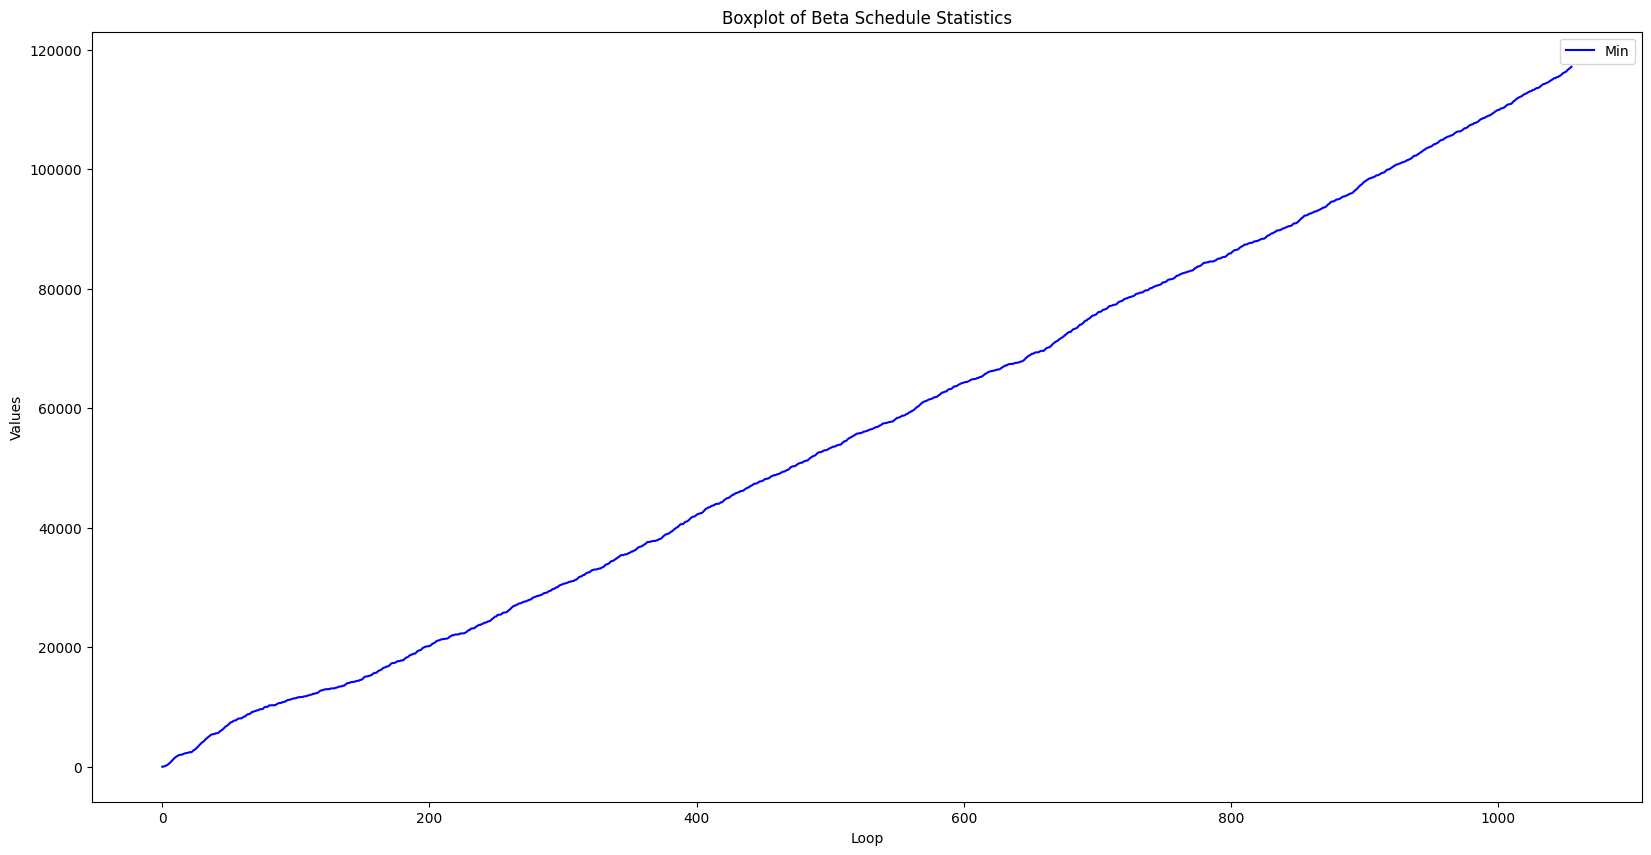

In [48]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 10))
plt.plot(min, label='Min', color='blue')
plt.legend()
plt.title('Boxplot of Beta Schedule Statistics')
plt.xlabel('Loop')
plt.ylabel('Values')
plt.show()

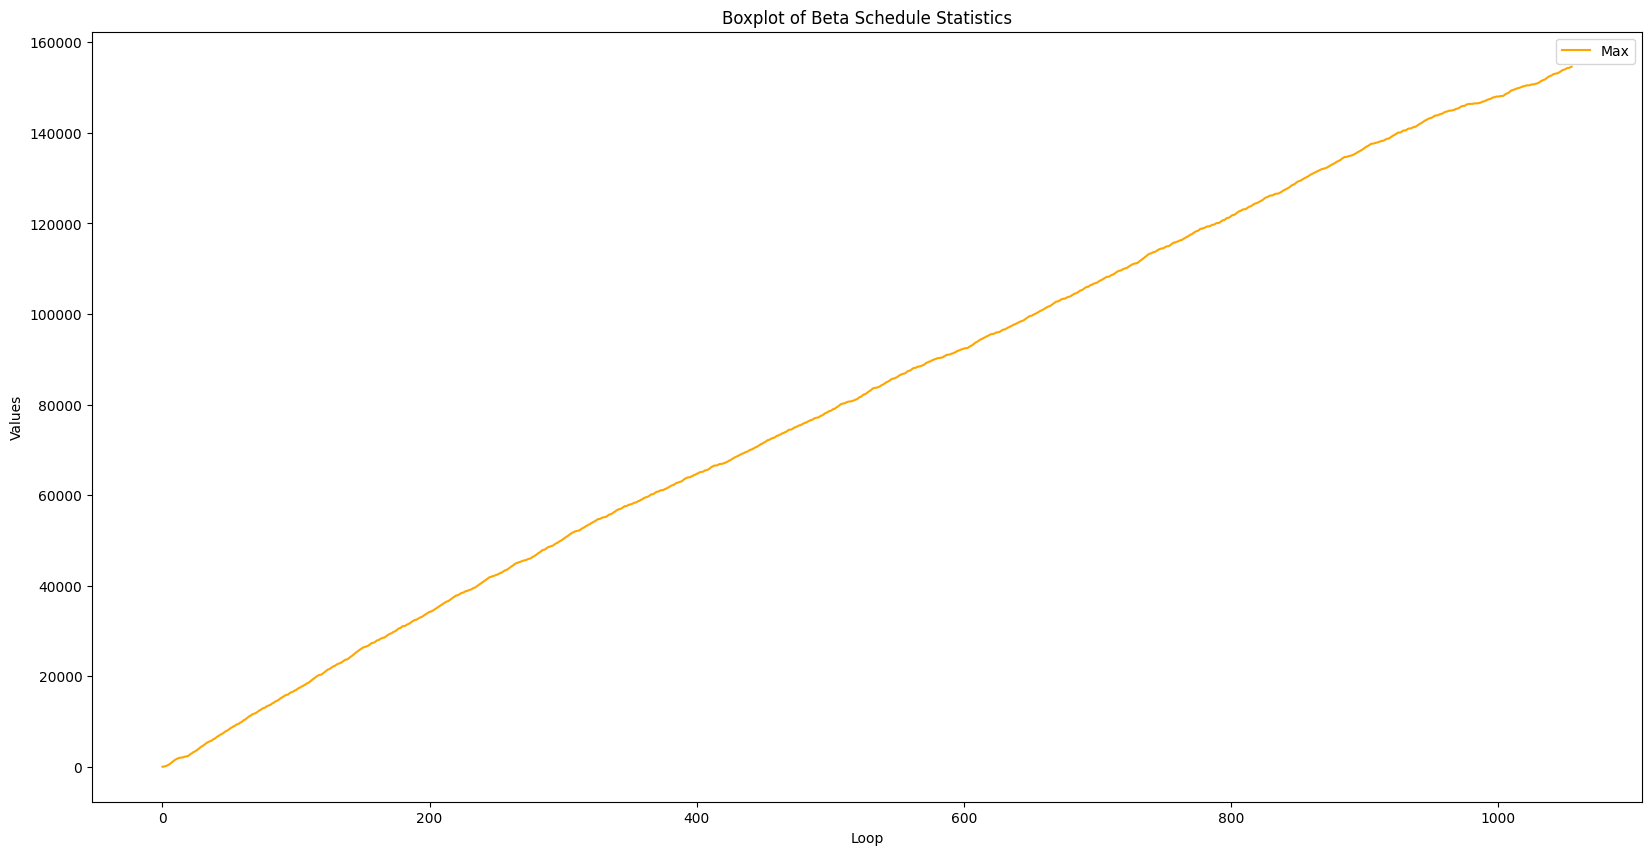

In [49]:
plt.figure(figsize=(20, 10))
plt.plot(max, label='Max', color='orange')
plt.legend()
plt.title('Boxplot of Beta Schedule Statistics')
plt.xlabel('Loop')
plt.ylabel('Values')
plt.show()

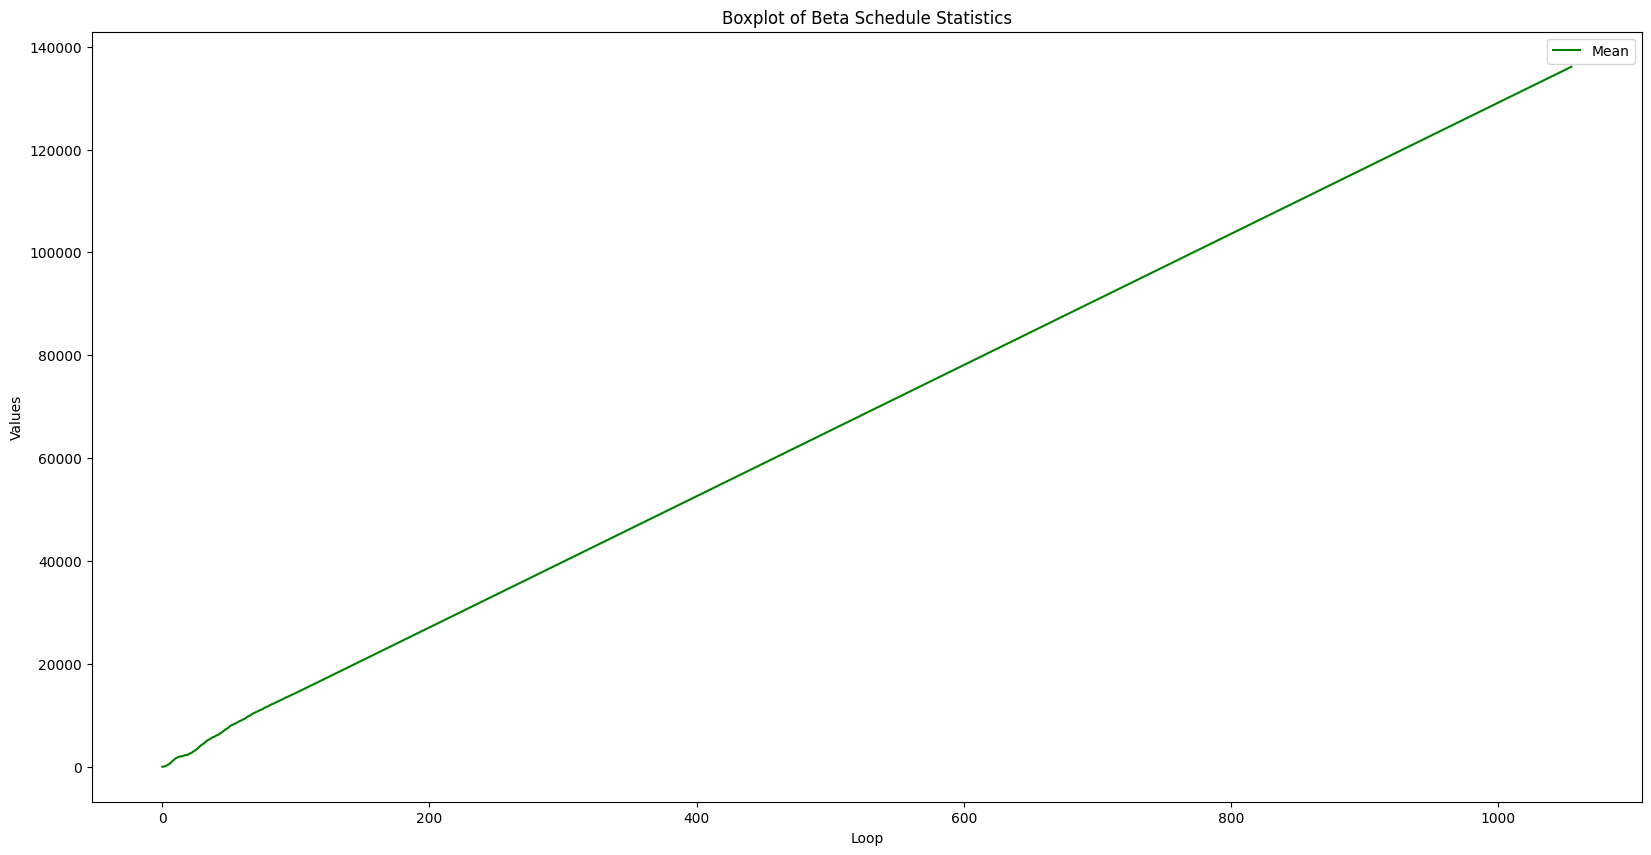

In [50]:
plt.figure(figsize=(20, 10))
plt.plot(mean, label='Mean', color='green')
plt.legend()
plt.title('Boxplot of Beta Schedule Statistics')
plt.xlabel('Loop')
plt.ylabel('Values')
plt.show()

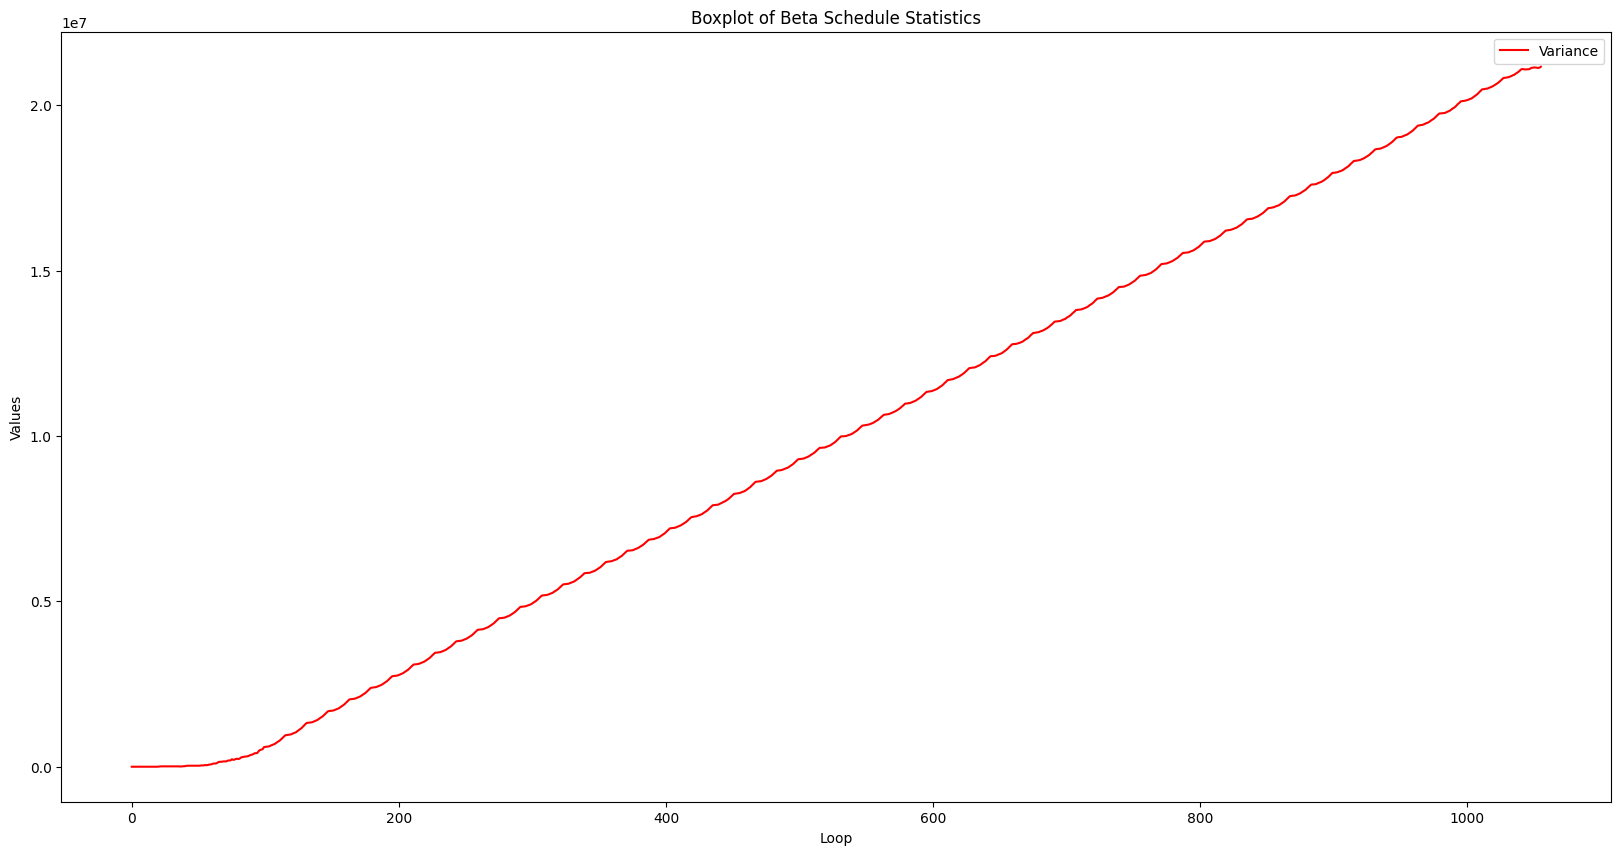

In [51]:
plt.figure(figsize=(20, 10))
plt.plot(var, label='Variance', color='red')
plt.legend()
plt.title('Boxplot of Beta Schedule Statistics')
plt.xlabel('Loop')
plt.ylabel('Values')
plt.show()

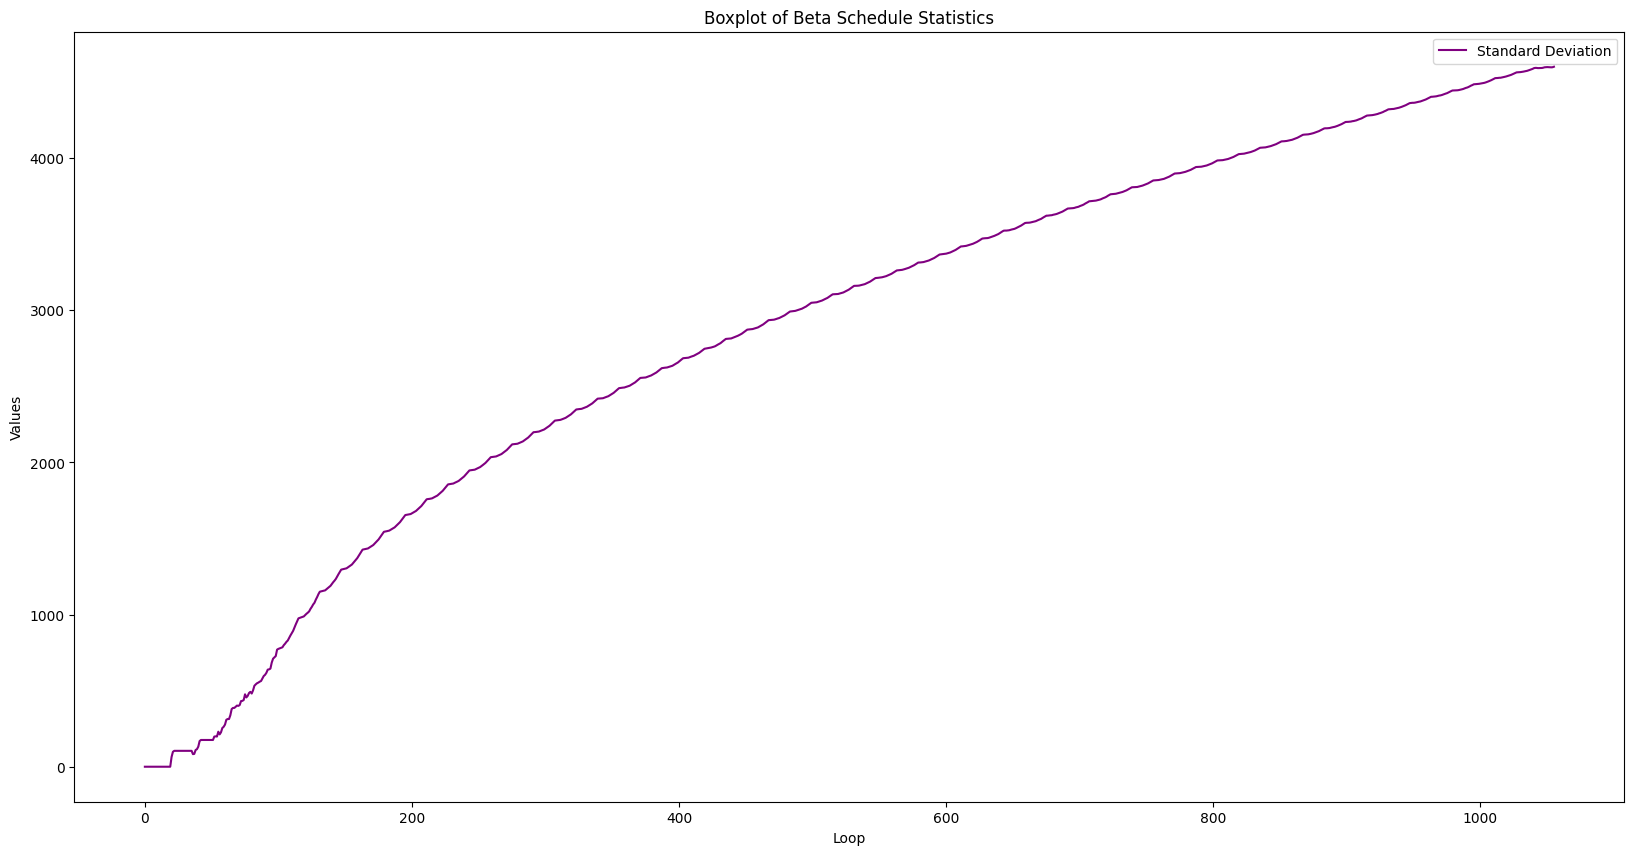

In [52]:
plt.figure(figsize=(20, 10))
plt.plot(std, label='Standard Deviation', color='purple')
plt.legend()
plt.title('Boxplot of Beta Schedule Statistics')
plt.xlabel('Loop')
plt.ylabel('Values')
plt.show()

In [53]:
import mlx.core as mx
betas = mx.linspace(start=1e-4, stop=2e-2, num=len(beta_schedule[0]))
betas = np.array(betas, dtype=np.float64)
print(betas)
print(beta_schedule[0])
candidate_betas = np.multiply(beta_schedule[0], betas)
candidate_betas = np.array(candidate_betas, dtype=np.float64)
print(candidate_betas)

str_max = 0
for i in range(0, len(beta_schedule)):
    str_len = len(str(beta_schedule[i]))
    if str_len > str_max:
        str_max = str_len
print(f"Max String Length: {str_max}")

[9.99999975e-05 1.18862554e-04 1.37725117e-04 1.56587674e-04 1.75450230e-04 1.94312801e-04 2.13175343e-04 2.32037914e-04 2.50900455e-04 2.69763026e-04 2.88625597e-04 3.07488139e-04 3.26350681e-04 3.45213281e-04 3.64075822e-04 3.82938364e-04 4.01800935e-04 4.20663477e-04 4.39526048e-04 4.58388618e-04 4.77251189e-04 4.96113731e-04 5.14976273e-04 5.33838873e-04 5.52701415e-04 5.71563956e-04 5.90426556e-04 6.09289040e-04 6.28151640e-04 6.47014240e-04 6.65876723e-04 6.84739323e-04 7.03601865e-04 7.22464407e-04 7.41326949e-04 7.60189607e-04 7.79052149e-04 7.97914632e-04 8.16777232e-04 8.35639716e-04 8.54502374e-04 8.73364974e-04 8.92227457e-04 9.11090057e-04 9.29952541e-04 9.48815199e-04 9.67677683e-04 9.86540224e-04 1.00540277e-03 1.02426542e-03 1.04312797e-03 1.06199051e-03 1.08085305e-03 1.09971559e-03 1.11857813e-03 1.13744067e-03 1.15630333e-03 1.17516587e-03 1.19402842e-03 1.21289096e-03 1.23175350e-03 1.25061604e-03 1.26947858e-03 1.28834124e-03 1.30720378e-03 1.32606633e-03 1.3449287

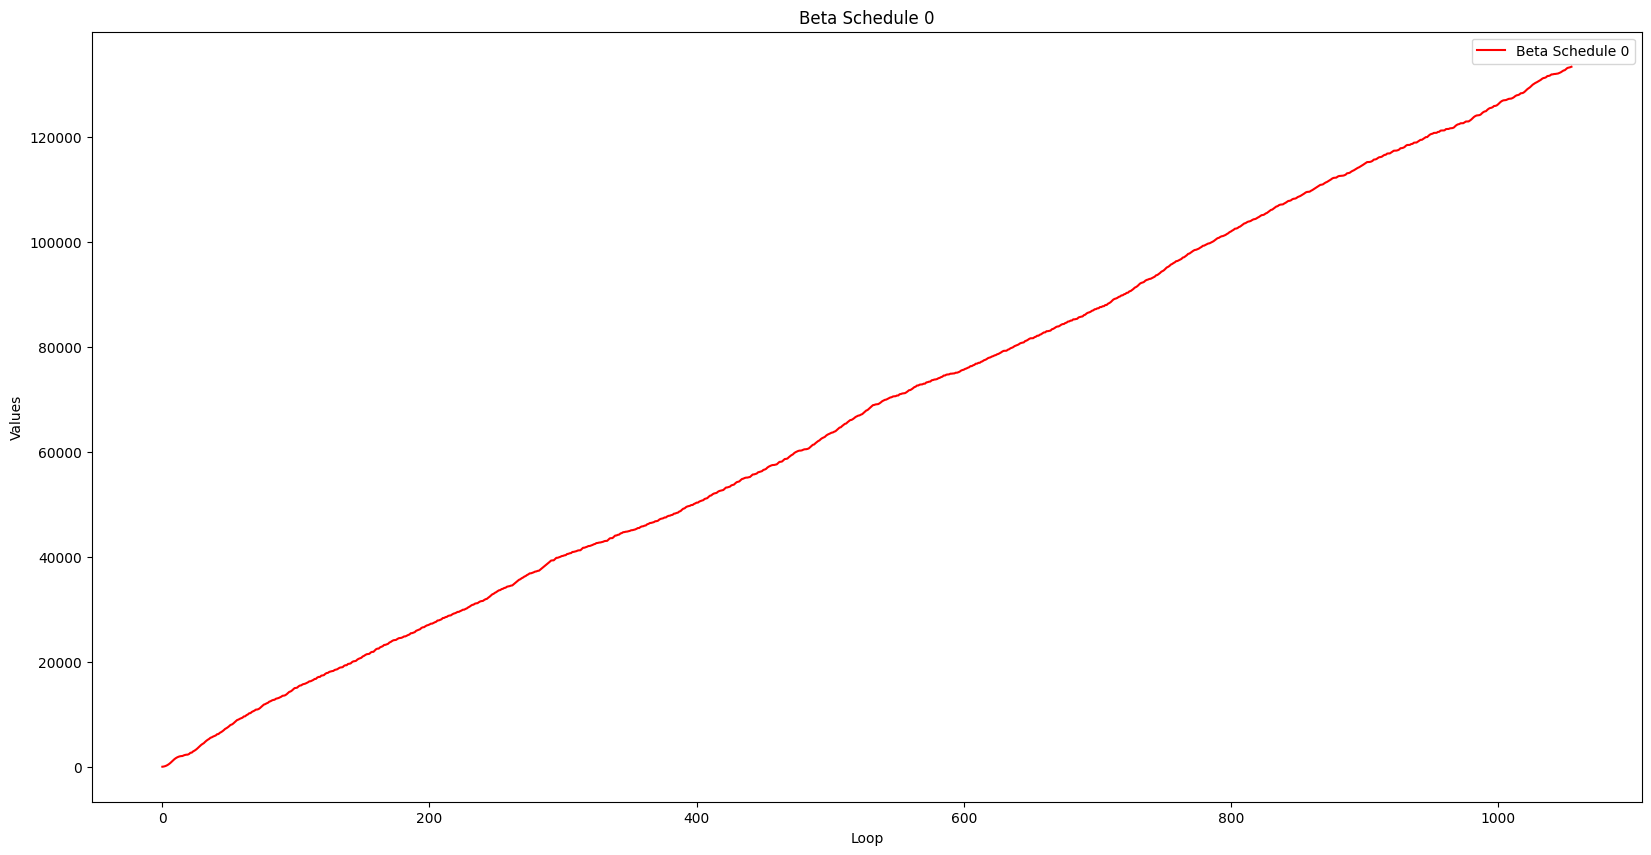

In [54]:
plt.figure(figsize=(20, 10))
plt.plot(beta_schedule[0], label='Beta Schedule 0', color='red')
plt.legend()
plt.title('Beta Schedule 0')
plt.xlabel('Loop')
plt.ylabel('Values')
plt.show()

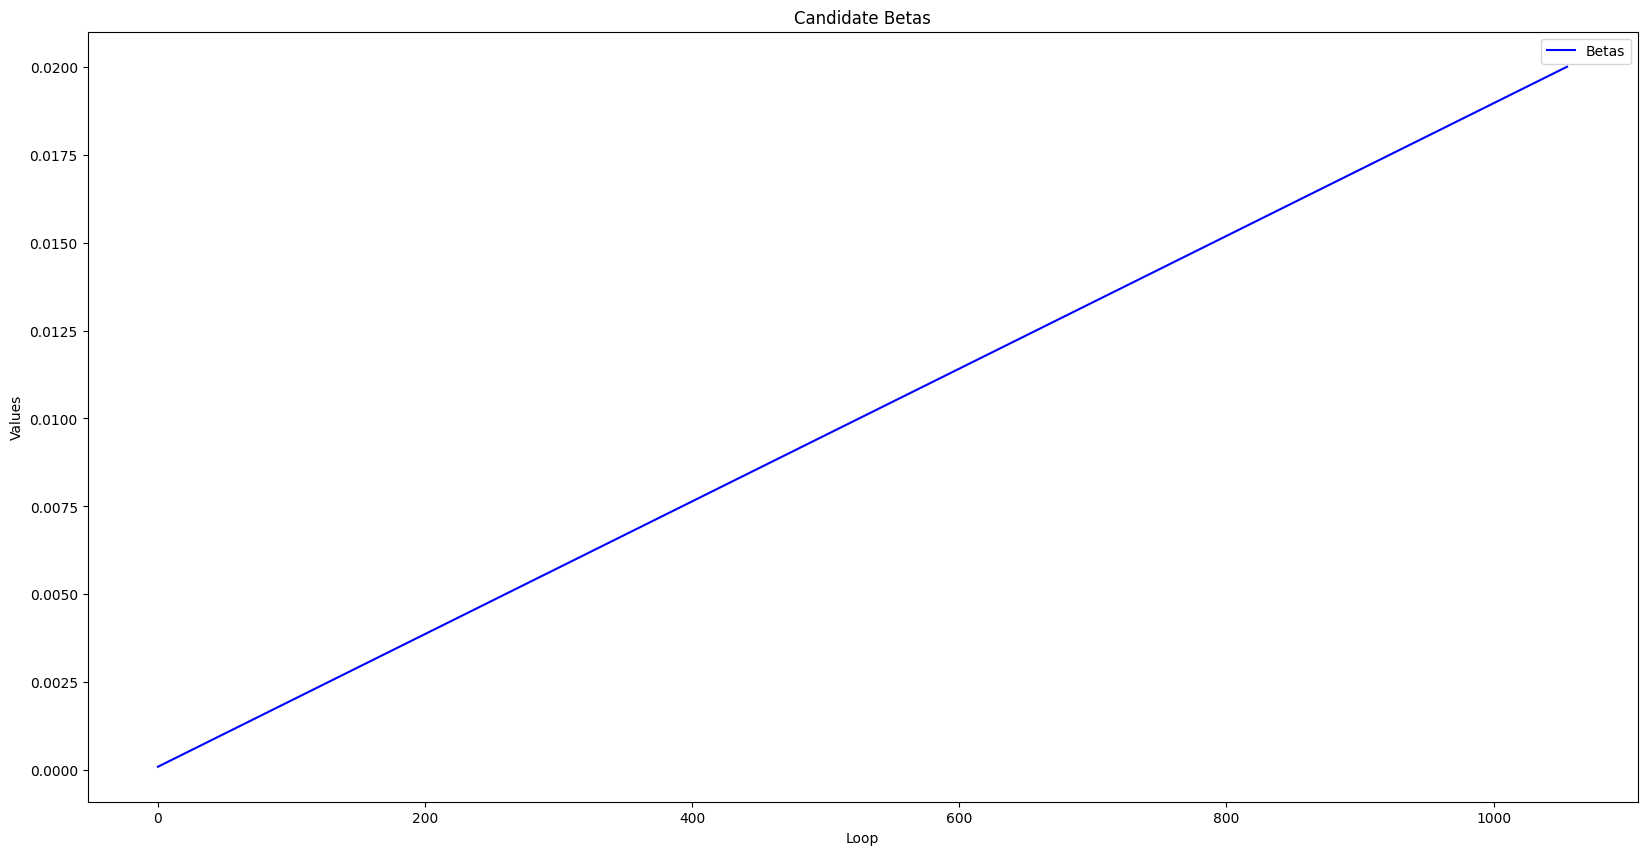

In [55]:
plt.figure(figsize=(20, 10))
plt.plot(betas, label='Betas', color='blue')
plt.legend()
plt.title('Candidate Betas')
plt.xlabel('Loop')
plt.ylabel('Values')
plt.show()

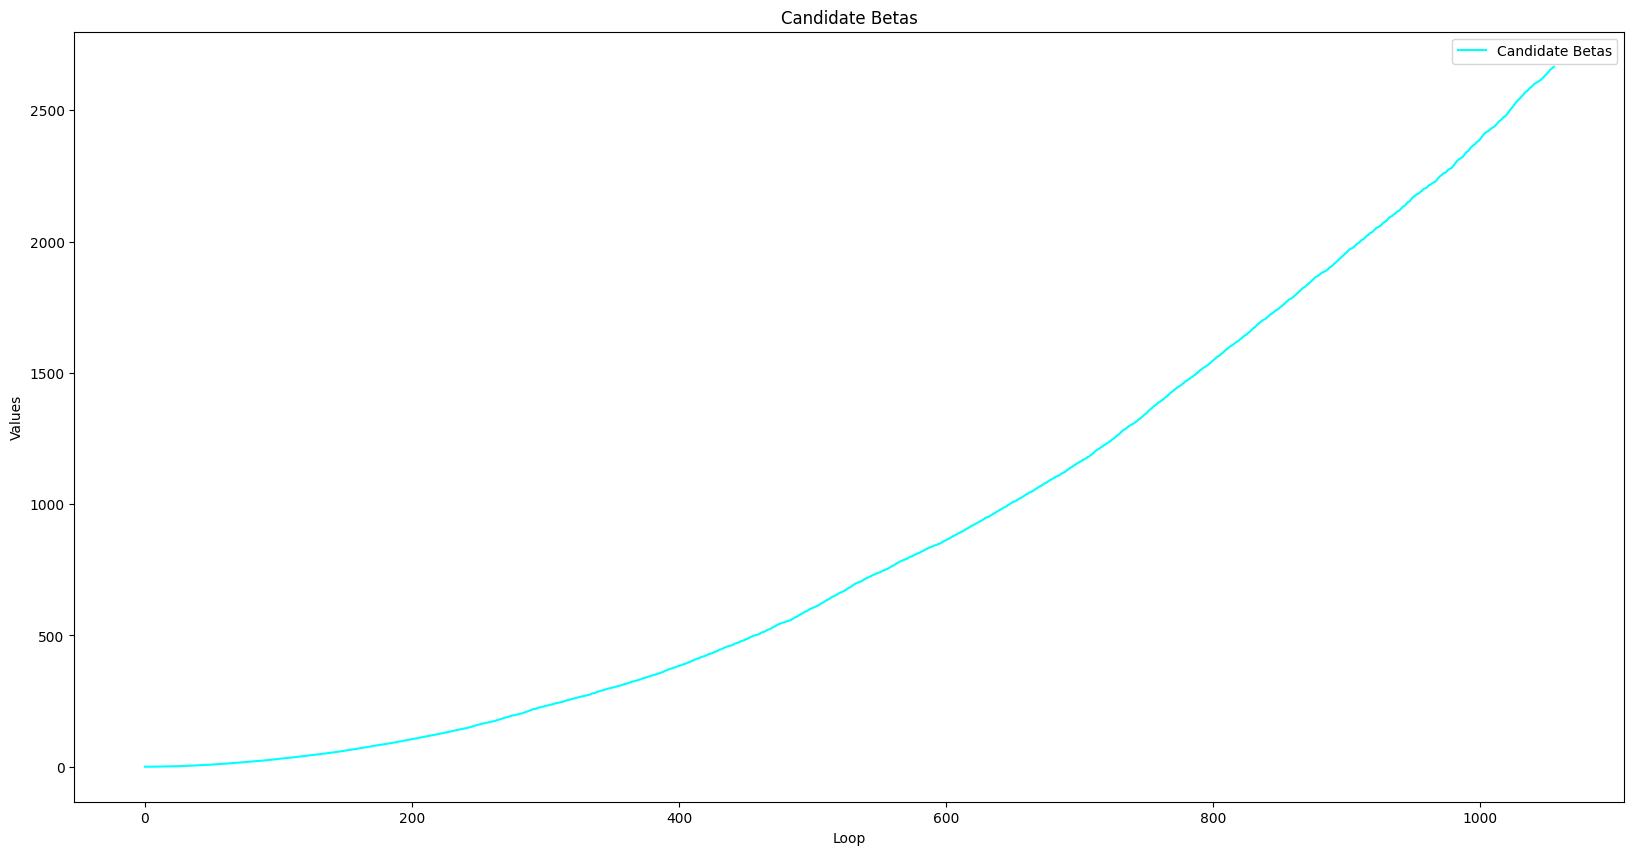

In [56]:
plt.figure(figsize=(20, 10))
plt.plot(candidate_betas, label='Candidate Betas', color='cyan')
plt.legend()
plt.title('Candidate Betas')
plt.xlabel('Loop')
plt.ylabel('Values')
plt.show()